In [1]:
# =========================================
# Cell 1: Imports and Path Configuration
# Purpose:
# - Import required libraries for modeling
# - Configure dataset paths
# =========================================

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

# Define project paths
BASE_DIR = Path("..").resolve()
DATA_PROCESSED = BASE_DIR / "data" / "processed"

print("Project directory:", BASE_DIR)

Project directory: C:\Users\jsrin\post_discharge_strategy


In [3]:
# =========================================
# Cell 2: Load Modeling Dataset
# Purpose:
# - Load cleaned and aggregated hospital dataset
# - Confirm shape and structure
# =========================================

path = DATA_PROCESSED / "cms_hrrp_hospital_modeling_dataset.parquet"

df = pd.read_parquet(path)

print("Loaded dataset shape:", df.shape)
df.head()

Loaded dataset shape: (2862, 10)


,facility_id,facility_name,state,avg_err,avg_err_z,err_std,total_discharges,measure_count,volume_weighted_err,stability_z
0,10001,SOUTHEAST HEALTH MEDICAL CENTER,AL,0.971467,-0.416945,0.045302,1748.0,6,0.997290,-0.404628
1,10005,MARSHALL MEDICAL CENTERS,AL,0.890575,-1.498188,0.069261,625.0,4,0.894681,0.317081
2,10006,NORTH ALABAMA MEDICAL CENTER,AL,0.992550,-0.163915,0.049782,1689.0,6,0.988214,-0.269665
3,10007,MIZELL MEMORIAL HOSPITAL,AL,1.028350,0.493505,0.042453,120.0,4,1.054225,-0.490432
4,10011,ST. VINCENT'S EAST,AL,1.025167,0.385934,0.060061,915.0,6,1.040568,0.039939


In [5]:
# =========================================
# Cell 3: Drop Rows Missing Modeling Target
# Purpose:
# - Remove hospitals without volume_weighted_err
# - Ensure dataset is valid for supervised learning
# =========================================

print("Missing values before drop:")
print(df.isna().sum())

df = df.dropna(subset=["volume_weighted_err"])

print("\nShape after dropping missing target rows:", df.shape)

Missing values before drop:
facility_id              0
facility_name            0
state                    0
avg_err                  0
avg_err_z                0
err_std                  0
total_discharges         0
measure_count            0
volume_weighted_err    366
stability_z              0
dtype: int64

Shape after dropping missing target rows: (2496, 10)


In [7]:
# =========================================
# Cell 4: Define Target Variable
# Purpose:
# - Convert volume_weighted_err into binary classification target
# - High risk = ERR > 1.0
# =========================================

df["high_risk"] = (df["volume_weighted_err"] > 1.0).astype(int)

print("Target distribution (counts):")
print(df["high_risk"].value_counts())

print("\nTarget distribution (proportion):")
print(df["high_risk"].value_counts(normalize=True).round(3))

Target distribution (counts):
high_risk
1    1367
0    1129
Name: count, dtype: int64

Target distribution (proportion):
high_risk
1    0.548
0    0.452
Name: proportion, dtype: float64


In [23]:
# =========================================
# Cell 5: Feature Matrix Preparation (Leakage-Free)
# Purpose:
# - Remove target and any leakage variables
# - Remove identifier columns
# =========================================

X = df.select_dtypes(include=[np.number]).drop(
    columns=["high_risk", "volume_weighted_err", "facility_id"]
)

y = df["high_risk"]

print("Feature columns used:")
print(X.columns.tolist())
print("Feature matrix shape:", X.shape)

Feature columns used:
['avg_err', 'avg_err_z', 'err_std', 'total_discharges', 'measure_count', 'stability_z']
Feature matrix shape: (2496, 6)


In [25]:
# =========================================
# Cell 6: Train-Test Split
# Purpose:
# - Create stratified split
# - Preserve class balance
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (1996, 6)
Test size: (500, 6)


In [27]:
# =========================================
# Cell 7: Baseline Model - Logistic Regression
# Purpose:
# - Establish linear baseline
# - Standardize features
# =========================================

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, digits=3))

Logistic Regression Results
ROC-AUC: 0.9397164265874297
Balanced Accuracy: 0.8678218461339706

Confusion Matrix:
 [[191  35]
 [ 30 244]]

Classification Report:
               precision    recall  f1-score   support

           0      0.864     0.845     0.855       226
           1      0.875     0.891     0.882       274

    accuracy                          0.870       500
   macro avg      0.869     0.868     0.869       500
weighted avg      0.870     0.870     0.870       500



In [37]:
# =========================================
# Cell 8: Baseline Model - Random Forest
# Purpose:
# - Compare nonlinear model against logistic regression
# - Evaluate improvement over linear baseline
# =========================================

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, digits=3))

Random Forest Results
ROC-AUC: 0.9465554550739615
Balanced Accuracy: 0.8770589755183773

Confusion Matrix:
 [[196  30]
 [ 31 243]]

Classification Report:
               precision    recall  f1-score   support

           0      0.863     0.867     0.865       226
           1      0.890     0.887     0.888       274

    accuracy                          0.878       500
   macro avg      0.877     0.877     0.877       500
weighted avg      0.878     0.878     0.878       500



In [39]:
# =========================================
# Cell 9: Baseline Comparison Summary
# Purpose:
# - Quantify improvement between models
# - Generate table for presentation slide
# =========================================

results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "ROC-AUC": roc_auc_score(y_test, y_prob_lr),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_lr)
    },
    {
        "Model": "Random Forest",
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_rf)
    }
]).sort_values("ROC-AUC", ascending=False)

results

,Model,ROC-AUC,Balanced Accuracy
1,Random Forest,0.946555,0.877059
0,Logistic Regression,0.939716,0.867822


<Figure size 640x480 with 0 Axes>

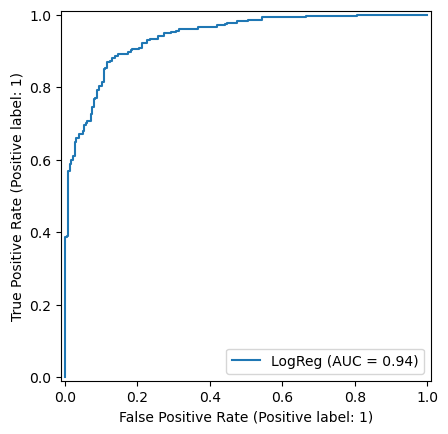

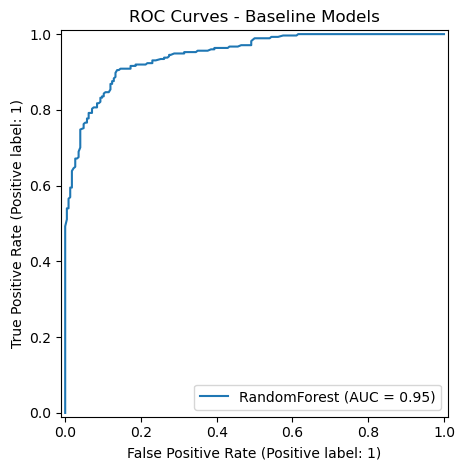

In [41]:
# =========================================
# Cell 10: ROC Curve Visualization
# Purpose:
# - Visual comparison of baseline models
# - Add visual evidence to presentation
# =========================================

from sklearn.metrics import RocCurveDisplay

plt.figure()
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name="LogReg")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="RandomForest")
plt.title("ROC Curves - Baseline Models")
plt.tight_layout()
plt.show()